## **Aprendizado por transferência**

Letícia Nunes de Souza Andrade

### **1. Introdução**

O uso de redes neurais profundas tem se tornado cada vez mais comum em diversas áreas, incluindo aplicações científicas como a biologia e a medicina. No entanto, o treinamento desses modelos geralmente exige grandes volumes de dados e alto custo computacional, o que nem sempre é viável em contextos experimentais. Em muitas situações, como na análise de imagens de microscopia ou dados biomédicos, a obtenção de conjuntos de dados extensos é limitada por fatores como custo, tempo e complexidade experimental.

Nesse cenário, o aprendizado por transferência (*transfer learning*) surge como uma abordagem eficiente, permitindo reutilizar o conhecimento adquirido por modelos previamente treinados em grandes bases de dados para resolver novos problemas relacionados. Em vez de iniciar o treinamento do zero, essa técnica aproveita padrões já aprendidos (como estruturas, formas e características visuais) e os adapta para tarefas mais específicas.

Dessa forma, o aprendizado por transferência não apenas reduz a necessidade de grandes volumes de dados, como também acelera o processo de treinamento e melhora o desempenho em problemas com dados limitados. Por isso, tem se consolidado como uma ferramenta fundamental em aplicações modernas de deep learning, especialmente em áreas científicas onde os dados são escassos e valiosos.

### **2. O que é *Transfer learning*?**

O aprendizado por transferência (transfer learning) é uma técnica em que um modelo treinado em uma tarefa é reutilizado para resolver outro problema relacionado. Em vez de treinar uma rede neural do zero, aproveita-se o conhecimento já aprendido, o que reduz a necessidade de grandes volumes de dados e de alto custo computacional.

Em redes neurais, as camadas iniciais aprendem padrões gerais, como bordas e texturas, enquanto as camadas finais aprendem características mais específicas. No transfer learning, essas representações iniciais são mantidas e adaptadas para uma nova tarefa.

Essa abordagem é especialmente importante em deep learning, pois permite aplicar modelos complexos mesmo em cenários com poucos dados, sendo amplamente utilizada em áreas como visão computacional e aplicações biomédicas.

Numa CNN treinada em ImageNet (dataset com 1,2 milhão de imagens e 1000 categorias), as camadas aprendem representações hierárquicas:

| Camada | O que aprende |
|--------|---------------|
| Primeiras camadas | Bordas, gradientes, texturas simples |
| Camadas intermediárias | Formas, padrões complexos |
| Últimas camadas | Partes de objetos, conceitos abstratos |
| Camada de saída | Classes específicas do dataset original |

As primeiras camadas são universais, bordas e texturas são úteis para qualquer tarefa de visão. Isso é o que transferimos.



### **3. Modelo pré-treinado vs Fine-tunning**

No aprendizado por transferência, existem duas abordagens principais para reutilizar um modelo pré-treinado: o uso como extrator de características (feature extractor) e o fine-tuning.

No caso do feature extractor, o modelo pré-treinado é mantido com seus pesos fixos, e apenas a camada final é substituída e treinada para a nova tarefa. Assim, a rede atua como uma extratora de padrões gerais, enquanto a parte final aprende a realizar a nova classificação.

Já no fine-tuning, parte das camadas do modelo também é ajustada durante o treinamento. Isso permite que o modelo adapte suas representações internas ao novo problema, geralmente resultando em melhor desempenho, especialmente quando há mais dados disponíveis.

De forma geral, o uso como extrator de características é mais simples e indicado quando há poucos dados, enquanto o fine-tuning é mais flexível e pode capturar melhor as especificidades da nova tarefa.

A seguir são comparados os custos computacionais relativos a cada uma dessas abordagens:

| | Treinar do zero | Feature Extraction | Fine-tuning |
|---|---|---|---|
| Dados necessários | Muito | Pouco | Médio |
| Custo computacional | Alto | Baixo | Médio |
| Risco de overfitting | Alto | Baixo | Médio |
| Flexibilidade | Total | Baixa | Alta |

### **4. Vantagens com poucos dados**

Redes neurais profundas têm milhões de parâmetros. Com poucos dados, o modelo "memoriza" os exemplos de treino em vez de aprender padrões gerais, criando um overfitting.

O transfer learning surge justamente como uma estratégia para contornar esse problema. Ao utilizar um modelo pré-treinado, partimos de uma inicialização inteligente: os pesos já não são aleatórios, mas carregam representações úteis aprendidas previamente. 

Além disso, ao congelar as camadas iniciais da rede, reduzimos significativamente o número de parâmetros que precisam ser ajustados, concentrando o treinamento apenas nas camadas finais. 

Isso também introduz uma forma de regularização implícita, já que os pesos pré-treinados funcionam como um tipo de conhecimento prévio (um prior informativo).

### **5. Exemplo simples: Feature extration com MobileNetV2**

Usaremos o MobileNetV2 pré-treinado no ImageNet para classificar imagens de **aviões vs. automóveis** do CIFAR-10, um dataset simples para ilustrar o conceito sem dependências externas.

Para tornar o exemplo mais realista, usamos apenas 2000 imagens de treino, simulando o cenário de escassez de dados típico em biologia.

**5.1 Importando dependências**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import torchvision

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Dispositivo: {DEVICE}")

PyTorch : 2.10.0+cpu
Dispositivo: cpu


**5.2 Carregando o dataset (CIFAR-10)**

O CIFAR-10 já vem disponível no `torchvision`.
Usamos apenas 2 das 10 classes (**avião** e **automóvel**) para manter o exemplo binário e didático.

In [ ]:
# Carrega CIFAR-10 como arrays numpy
cifar_tr = torchvision.datasets.CIFAR10(root='/tmp/cifar', train=True,  download=True)
cifar_te = torchvision.datasets.CIFAR10(root='/tmp/cifar', train=False, download=True)

x_train_full = np.array(cifar_tr.data)            # (50000, 32, 32, 3) uint8
y_train_full = np.array(cifar_tr.targets)          # (50000,)
x_test_full  = np.array(cifar_te.data)
y_test_full  = np.array(cifar_te.targets)

CLASSES_ALVO = [0, 1]
CLASS_NAMES  = ['Avião', 'Automóvel']
IMG_SIZE     = 96      # mínimo aceito pelo MobileNetV2
BATCH_SIZE   = 32
N_TRAIN      = 2000
N_VAL        = 500

def filtrar_classes(x, y, classes):
    """Filtra classes desejadas e remapeia rótulos para 0, 1."""
    mask  = np.isin(y, classes)
    remap = {c: i for i, c in enumerate(classes)}
    return x[mask], np.array([remap[yi] for yi in y[mask]])

x_tr, y_tr = filtrar_classes(x_train_full, y_train_full, CLASSES_ALVO)
x_te, y_te = filtrar_classes(x_test_full,  y_test_full,  CLASSES_ALVO)

x_tr, y_tr   = x_tr[:N_TRAIN], y_tr[:N_TRAIN]
x_val, y_val = x_te[:N_VAL],   y_te[:N_VAL]
x_te, y_te   = x_te[N_VAL:],   y_te[N_VAL:]

# ── Dataset e transforms PyTorch ──
mean = [0.485, 0.456, 0.406]   # média ImageNet
std  = [0.229, 0.224, 0.225]   # desvio ImageNet

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ToTensor(),                   # uint8 [0,255] → float [0,1]
    T.Normalize(mean, std),
])
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean, std),
])

class CIFARDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x, self.y, self.transform = x, y, transform
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        img = Image.fromarray(self.x[idx])
        if self.transform:
            img = self.transform(img)
        return img, int(self.y[idx])

ds_train = DataLoader(CIFARDataset(x_tr,  y_tr,  train_transform), batch_size=BATCH_SIZE, shuffle=True)
ds_val   = DataLoader(CIFARDataset(x_val, y_val, val_transform),   batch_size=BATCH_SIZE)
ds_test  = DataLoader(CIFARDataset(x_te,  y_te,  val_transform),   batch_size=BATCH_SIZE)

n_disp = int(np.isin(y_train_full, CLASSES_ALVO).sum())
print(f"Treino : {len(x_tr)} de {n_disp} disponíveis — simulando escassez de dados")
print(f"Validação: {len(x_val)} | Teste: {len(x_te)}")

100%|██████████| 170M/170M [00:28<00:00, 5.94MB/s] 


Treino : 2000 de 10000 disponíveis — simulando escassez de dados
Validação: 500 | Teste: 1500


**5.3 Visualização de algumas imagens**

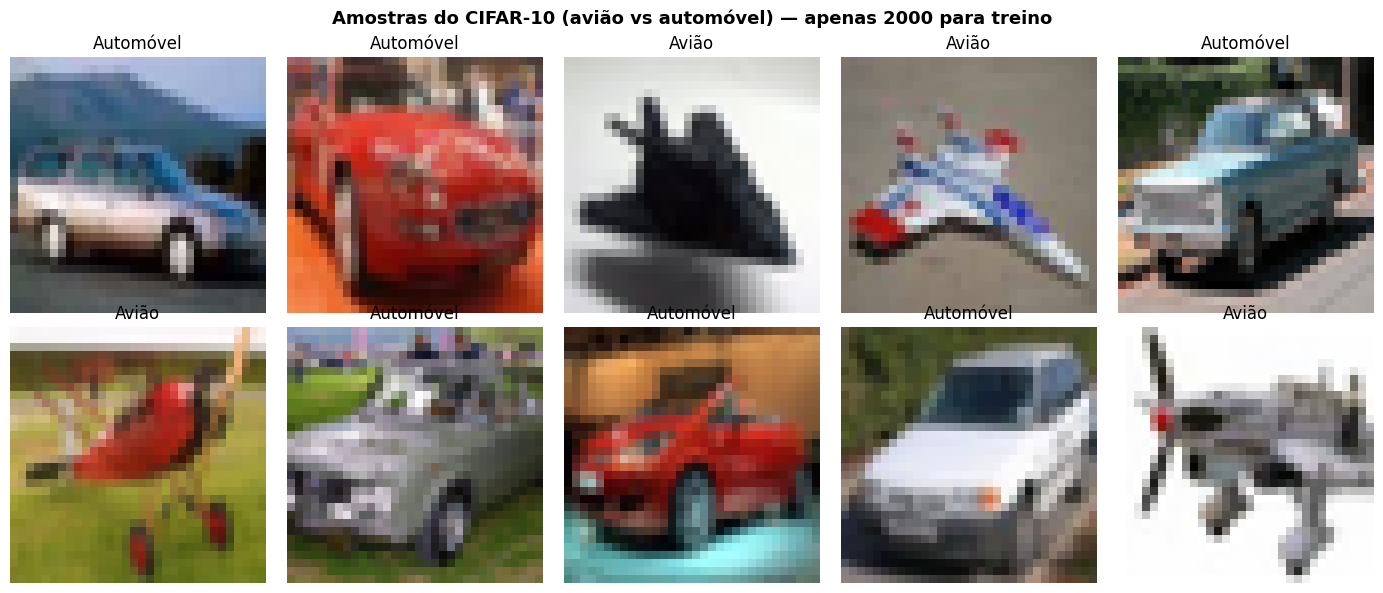

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_tr[i])
    ax.set_title(CLASS_NAMES[y_tr[i]], fontsize=12)
    ax.axis('off')
plt.suptitle('Amostras do CIFAR-10 (avião vs automóvel) — apenas 2000 para treino',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**5.4 Construindo o modelo — Feature Extraction com MobileNetV2**

Agora, carregamos o **MobileNetV2** com pesos pré-treinados no ImageNet e congelamos todos os seus parâmetros. Substituímos apenas a última camada linear do classificador para se adequar ao nosso problema binário (2 classes). Só essa nova camada será treinada.

In [4]:
# Carrega MobileNetV2 pré-treinado no ImageNet
model_fe = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Congela todos os parâmetros da base
for param in model_fe.parameters():
    param.requires_grad = False

# Substitui a cabeça de classificação (1280 → 2 classes)
in_features = model_fe.classifier[1].in_features   # 1280
model_fe.classifier[1] = nn.Linear(in_features, 2)
model_fe = model_fe.to(DEVICE)

n_total     = sum(p.numel() for p in model_fe.parameters())
n_trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"Parâmetros treináveis : {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.1f}%)")
print("→ Apenas a nova camada Dense é treinada. A base está totalmente congelada.")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\leticia25029/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 25.7MB/s]


Parâmetros treináveis : 2,562 / 2,226,434 (0.1%)
→ Apenas a nova camada Dense é treinada. A base está totalmente congelada.


**5.5 Treinamento — Fase 1: Feature Extraction**

Nesta etapa, configuramos o processo de treinamento do modelo, definindo o otimizador, a função de perda e a métrica de avaliação. Em seguida, realizamos o treinamento utilizando os dados de treino e validamos o desempenho ao longo das épocas com um conjunto de validação.

In [5]:
def train_epoch(model, loader, criterion, optimizer):
    """Executa uma época de treino e retorna (loss_médio, acurácia)."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion):
    """Avalia o modelo em um loader e retorna (loss_médio, acurácia)."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * len(labels)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total

criterion_fe = nn.CrossEntropyLoss()
optimizer_fe = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_fe.parameters()),
    lr=1e-3)

history_fe = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
EPOCHS_FE_SIMPLE = 5

for epoch in range(1, EPOCHS_FE_SIMPLE + 1):
    tr_loss, tr_acc = train_epoch(model_fe, ds_train, criterion_fe, optimizer_fe)
    vl_loss, vl_acc = eval_epoch(model_fe,  ds_val,   criterion_fe)
    history_fe['train_loss'].append(tr_loss); history_fe['train_acc'].append(tr_acc)
    history_fe['val_loss'].append(vl_loss);   history_fe['val_acc'].append(vl_acc)
    print(f"Época {epoch}/{EPOCHS_FE_SIMPLE} — loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
          f"val_loss: {vl_loss:.4f}  val_acc: {vl_acc:.4f}")

Época 1/5 — loss: 0.3638  acc: 0.8310 | val_loss: 0.3269  val_acc: 0.8620
Época 2/5 — loss: 0.2422  acc: 0.9035 | val_loss: 0.2364  val_acc: 0.9140
Época 3/5 — loss: 0.2501  acc: 0.9010 | val_loss: 0.2341  val_acc: 0.9140
Época 4/5 — loss: 0.2089  acc: 0.9215 | val_loss: 0.2353  val_acc: 0.9060
Época 5/5 — loss: 0.2149  acc: 0.9080 | val_loss: 0.2032  val_acc: 0.9240


**5.6 Fase 2: Fine-tuning — descongelando as últimas camadas**

In [6]:
# Descongela as camadas a partir da camada 100 da MobileNetV2 (features[-3:] e classifier)
# MobileNetV2.features é um Sequential de 19 blocos (0-18)
fine_tune_from = 14   # descongela os últimos 5 blocos
for i, block in enumerate(model_fe.features):
    for param in block.parameters():
        param.requires_grad = (i >= fine_tune_from)
# Mantém o classificador treinável
for param in model_fe.classifier.parameters():
    param.requires_grad = True

n_trainable_ft = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
print(f"Parâmetros treináveis após descongelar: {n_trainable_ft:,}")

# LR muito menor para não destruir os pesos pré-treinados
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_fe.parameters()),
    lr=1e-5)

EPOCHS_FT_SIMPLE = 5
history_ft = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS_FT_SIMPLE + 1):
    tr_loss, tr_acc = train_epoch(model_fe, ds_train, criterion_fe, optimizer_ft)
    vl_loss, vl_acc = eval_epoch(model_fe,  ds_val,   criterion_fe)
    history_ft['train_loss'].append(tr_loss); history_ft['train_acc'].append(tr_acc)
    history_ft['val_loss'].append(vl_loss);   history_ft['val_acc'].append(vl_acc)
    print(f"Época {epoch}/{EPOCHS_FT_SIMPLE} — loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
          f"val_loss: {vl_loss:.4f}  val_acc: {vl_acc:.4f}")

Parâmetros treináveis após descongelar: 1,683,906
Época 1/5 — loss: 0.2021  acc: 0.9290 | val_loss: 0.1844  val_acc: 0.9240
Época 2/5 — loss: 0.1634  acc: 0.9380 | val_loss: 0.1664  val_acc: 0.9240
Época 3/5 — loss: 0.1702  acc: 0.9350 | val_loss: 0.1509  val_acc: 0.9340
Época 4/5 — loss: 0.1613  acc: 0.9345 | val_loss: 0.1367  val_acc: 0.9520
Época 5/5 — loss: 0.1313  acc: 0.9530 | val_loss: 0.1321  val_acc: 0.9460


**5.7 Visualizando o treinamento**

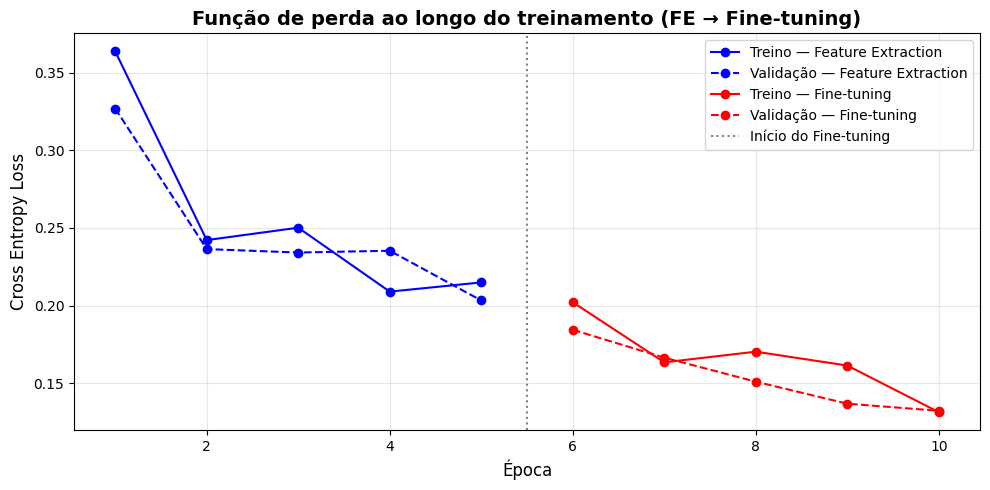

In [29]:
def plot_training(hist_fe, hist_ft):
    acc_fe = hist_fe['train_loss'];  val_fe = hist_fe['val_loss']
    acc_ft = hist_ft['train_loss'];  val_ft = hist_ft['val_loss']
    n_fe = len(acc_fe)
    epochs_fe = range(1, n_fe + 1)
    epochs_ft = range(n_fe + 1, n_fe + len(acc_ft) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs_fe, acc_fe,  'b-o',  label='Treino — Feature Extraction')
    ax.plot(epochs_fe, val_fe,  'b--o', label='Validação — Feature Extraction')
    ax.plot(epochs_ft, acc_ft,  'r-o',  label='Treino — Fine-tuning')
    ax.plot(epochs_ft, val_ft,  'r--o', label='Validação — Fine-tuning')
    ax.axvline(x=n_fe + 0.5, color='gray', linestyle=':', label='Início do Fine-tuning')
    ax.set_xlabel('Época', fontsize=12)
    ax.set_ylabel('Cross Entropy Loss', fontsize=12)
    ax.set_title('Função de perda ao longo do treinamento (FE → Fine-tuning)', fontsize=14, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_training(history_fe, history_ft)

Cross Entropy Loss mede o erro entre a distribuição de probabilidade prevista pelo modelo e a distribuição real, penalizando previsões incorretas e pouco confiantes.

### **6. Aplicação Biológica: Classificação de Subtipos de Células Sanguíneas**

**6.1 Contexto**

A identificação de subtipos de leucócitos (glóbulos brancos) ao microscópio é uma tarefa clínica fundamental para o diagnóstico de infecções, leucemias e distúrbios imunológicos. Tradicionalmente realizada por hematologistas, a automação por visão computacional pode acelerar diagnósticos e reduzir variabilidade inter-observador.

O desafio clássico: datasets médicos são pequenos, caros para rotular e sujeitos a regulações de privacidade. Com apenas ~347 imagens rotuladas, este é um caso de uso perfeito para Transfer Learning.

**6.2 Dataset**

Utilizaremos o dataset **Blood Cell Images**, composto por:
- **366 imagens** de esfregaços sanguíneos (640×480 px, microscopia óptica)
- **Labels em CSV**: cada imagem mapeada para um subtipo de leucócito
- **4 classes** (após limpeza): Neutrófilo, Eosinófilo, Linfócito e Monócito

A estrutura do dataset é:
```
dataset-master/
├── JPEGImages/          ← imagens (BloodImage_XXXXX.jpg)
├── labels.csv           ← mapeamento imagem → classe
└── Annotations/         ← bounding boxes XML (não usadas aqui)
```
*Observação:* mantenha a a pasta `dataset-master` no mesmo repositório do notebook.

> **Nota sobre o dataset:** algumas imagens têm múltiplos leucócitos de tipos diferentes (multi-label) — essas são descartadas para manter o problema como classificação simples. A classe Basófilo tem apenas 3 exemplos, insuficiente para treino, e também é removida.

**6.3 Pré-processamento e carregamento do dataset**

In [ ]:
# Importando as bibliotecas
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
DATASET_ROOT = './dataset-master'
IMG_DIR      = DATASET_ROOT + '/JPEGImages'
LABELS_CSV   = DATASET_ROOT + '/labels.csv'
IMG_SIZE_C   = 224      # EfficientNetB0 espera 224×224
BATCH_SIZE_C = 16
EPOCHS_FE    = 15
EPOCHS_FT    = 15
SEED         = 42

df = pd.read_csv(LABELS_CSV, index_col=0)

existing_ids = set(
    int(f.replace('BloodImage_', '').replace('.jpg', ''))
    for f in os.listdir(IMG_DIR) if f.endswith('.jpg'))

df = df.dropna(subset=['Category'])
df = df[~df['Category'].str.contains(',', na=False)]
df = df[df['Category'] != 'BASOPHIL']
df = df[df['Image'].isin(existing_ids)].reset_index(drop=True)

df['filepath'] = df['Image'].apply(lambda x: os.path.join(IMG_DIR, f'BloodImage_{x:05d}.jpg'))

CLASS_NAMES_C = sorted(df['Category'].unique())
NUM_CLASSES   = len(CLASS_NAMES_C)
class_to_idx  = {c: i for i, c in enumerate(CLASS_NAMES_C)}
df['label']   = df['Category'].map(class_to_idx)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES_C}")
print(f"\nDistribuição total:")
print(df['Category'].value_counts().to_string())
print(f"\nTotal de imagens utilizáveis: {len(df)}")

Classes (4): ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

Distribuição total:
Category
NEUTROPHIL    206
EOSINOPHIL     88
LYMPHOCYTE     33
MONOCYTE       20

Total de imagens utilizáveis: 347


Divisão estratificada em treino (70%), validação (15%) e teste (15%), mantendo a proporção de cada classe nos três conjuntos. O conjunto de teste é mantido completamente separado e só utilizado na avaliação final.

In [9]:
# Split estratificado: 70% treino, 15% validação, 15% teste
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['Category'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['Category'], random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Treino   : {len(train_df)} imagens")
print(train_df['Category'].value_counts().to_string())
print(f"\nValidação: {len(val_df)} imagens")
print(val_df['Category'].value_counts().to_string())
print(f"\nTeste    : {len(test_df)} imagens")
print(test_df['Category'].value_counts().to_string())

Treino   : 242 imagens
Category
NEUTROPHIL    144
EOSINOPHIL     61
LYMPHOCYTE     23
MONOCYTE       14

Validação: 52 imagens
Category
NEUTROPHIL    31
EOSINOPHIL    13
LYMPHOCYTE     5
MONOCYTE       3

Teste    : 53 imagens
Category
NEUTROPHIL    31
EOSINOPHIL    14
LYMPHOCYTE     5
MONOCYTE       3


Nesta etapa, preparamos os dados para o treinamento utilizando a API `torch.utils.data`. As imagens são carregadas do disco com PIL, redimensionadas e normalizadas com os parâmetros do ImageNet. Aplicamos data augmentation no conjunto de treino para aumentar a variabilidade e melhorar a generalização do modelo.

In [10]:
# Transforms para EfficientNetB0 (ImageNet mean/std)
mean_c = [0.485, 0.456, 0.406]
std_c  = [0.229, 0.224, 0.225]

cell_train_transform = T.Compose([
    T.Resize((IMG_SIZE_C, IMG_SIZE_C)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.1),
    T.ToTensor(),
    T.Normalize(mean_c, std_c),
])
cell_val_transform = T.Compose([
    T.Resize((IMG_SIZE_C, IMG_SIZE_C)),
    T.ToTensor(),
    T.Normalize(mean_c, std_c),
])

class BCCDDataset(Dataset):
    """Dataset de células sanguíneas a partir de um DataFrame."""
    def __init__(self, df, transform=None):
        self.filepaths = df['filepath'].values
        self.labels    = df['label'].values
        self.transform = transform
    def __len__(self):
        return len(self.filepaths)
    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

ds_train_c = DataLoader(BCCDDataset(train_df, cell_train_transform),
                        batch_size=BATCH_SIZE_C, shuffle=True)
ds_val_c   = DataLoader(BCCDDataset(val_df,   cell_val_transform),
                        batch_size=BATCH_SIZE_C)
ds_test_c  = DataLoader(BCCDDataset(test_df,  cell_val_transform),
                        batch_size=BATCH_SIZE_C)

print(f"Batches de treino    : {len(ds_train_c)}")
print(f"Batches de validação : {len(ds_val_c)}")
print(f"Batches de teste     : {len(ds_test_c)}")

Batches de treino    : 16
Batches de validação : 4
Batches de teste     : 4


**6.4 Explorando o dataset**

Nesta etapa, analisamos a distribuição das classes no conjunto de treino por meio de um gráfico de barras. Essa análise permite identificar possíveis desbalanceamentos no dataset, que podem impactar o desempenho e a capacidade de generalização do modelo.

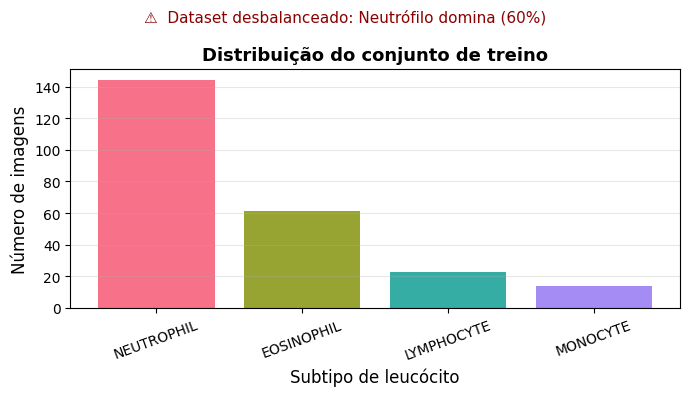

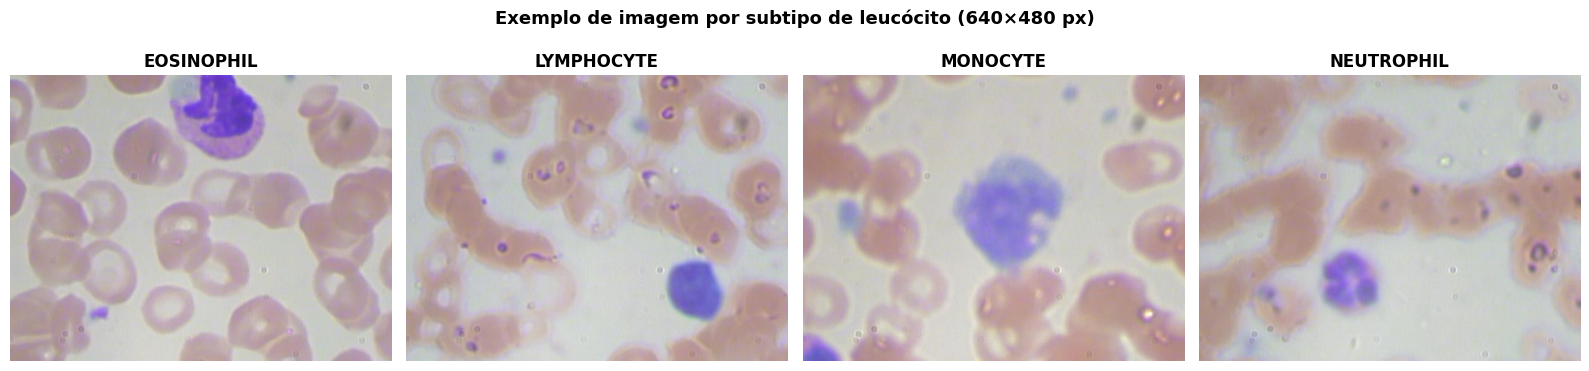

In [11]:
# Distribuição de classes — somente gráfico de barras
class_counts = train_df['Category'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(class_counts.index, class_counts.values,
       color=sns.color_palette('husl', NUM_CLASSES))
ax.set_xlabel('Subtipo de leucócito', fontsize=12)
ax.set_ylabel('Número de imagens', fontsize=12)
ax.set_title('Distribuição do conjunto de treino', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.suptitle('⚠️  Dataset desbalanceado: Neutrófilo domina (60%)', fontsize=11, color='darkred')
plt.tight_layout()
plt.show()

# Mostra uma imagem de cada classe
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
for cls_idx, cls_name in enumerate(CLASS_NAMES_C):
    sample = train_df[train_df['Category'] == cls_name].iloc[0]
    img = plt.imread(sample['filepath'])
    axes[cls_idx].imshow(img)
    axes[cls_idx].set_title(cls_name, fontsize=12, fontweight='bold')
    axes[cls_idx].axis('off')
plt.suptitle('Exemplo de imagem por subtipo de leucócito (640×480 px)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**6.5 Construindo o modelo — EfficientNetB0 com Transfer Learning**

A **EfficientNetB0** foi escolhida por ser:
- Eficiente (poucos parâmetros para alta acurácia)
- Treinada no ImageNet com escalonamento balanceado de profundidade/largura/resolução
- Amplamente usada em estudos de histopatologia e visão médica

Com apenas ~277 imagens de treino, Transfer Learning é realmente necessário.

In [12]:
def build_model_cells(num_classes, fine_tune_from=None):
    """
    Constrói modelo de Transfer Learning com EfficientNetB0.
    fine_tune_from=None → Feature Extraction (tudo congelado exceto a cabeça)
    fine_tune_from=N   → Fine-tuning (descongela features[N:])
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Congela todos os parâmetros da base
    for param in model.parameters():
        param.requires_grad = False

    # Fine-tuning: descongela os blocos a partir de fine_tune_from
    if fine_tune_from is not None:
        for i, block in enumerate(model.features):
            if i >= fine_tune_from:
                for param in block.parameters():
                    param.requires_grad = True

    # Substitui a cabeça de classificação
    in_features = model.classifier[1].in_features   # 1280
    model.classifier[1] = nn.Linear(in_features, num_classes)
    model = model.to(DEVICE)

    n_total     = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Treináveis: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.1f}%)")
    return model

print("=== FASE 1: Feature Extraction ===")
model_cells = build_model_cells(NUM_CLASSES)

=== FASE 1: Feature Extraction ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\leticia25029/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 17.7MB/s]


Treináveis: 5,124 / 4,012,672 (0.1%)


**6.6 Lidando com desbalanceamento de classes**

O dataset é muito desbalanceado (Neutrófilo = 60%, Monócito = 6%). Se ignorarmos isso, o modelo aprenderá a sempre prever Neutrófilo e ainda terá ~60% de acurácia, sem aprender nada útil.

A solução então é calcular pesos de classe para penalizar mais os erros nas classes minoritárias durante o treino.

In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}

# Tensor de pesos para nn.CrossEntropyLoss
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float).to(DEVICE)

print("Pesos de classe para balancear o treino:")
for cls_name, idx in class_to_idx.items():
    print(f"  {cls_name:12s} (idx {idx}): peso = {class_weight_dict[idx]:.3f}")
print("\n→ Classes minoritárias recebem peso maior: erros nelas 'custam mais' ao modelo.")

Pesos de classe para balancear o treino:
  EOSINOPHIL   (idx 0): peso = 0.992
  LYMPHOCYTE   (idx 1): peso = 2.630
  MONOCYTE     (idx 2): peso = 4.321
  NEUTROPHIL   (idx 3): peso = 0.420

→ Classes minoritárias recebem peso maior: erros nelas 'custam mais' ao modelo.


**6.7 Treinamento — Fase 1: Feature Extraction**

Nesta etapa, preparamos o modelo para treinar de forma mais eficiente e inteligente. Definimos como ele será avaliado durante o treinamento e utilizamos alguns mecanismos que ajudam a melhorar o aprendizado, como parar automaticamente quando não houver mais melhora, ajustar a velocidade de aprendizado e salvar a melhor versão do modelo.

Além disso, consideramos o desbalanceamento dos dados, dando mais importância às classes com menos exemplos. Por fim, iniciamos o treinamento do modelo utilizando os dados preparados anteriormente.

In [15]:
criterion_cells = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_cells  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_cells.parameters()), lr=1e-3)
scheduler_cells  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cells, factor=0.5, patience=3)

best_val_acc  = 0.0
patience_cnt  = 0
PATIENCE      = 6
hist_cells_fe = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Iniciando treinamento — Feature Extraction...")
for epoch in range(1, EPOCHS_FE + 1):
    tr_loss, tr_acc = train_epoch(model_cells, ds_train_c, criterion_cells, optimizer_cells)
    vl_loss, vl_acc = eval_epoch(model_cells,  ds_val_c,   criterion_cells)
    scheduler_cells.step(vl_loss)

    hist_cells_fe['train_loss'].append(tr_loss); hist_cells_fe['train_acc'].append(tr_acc)
    hist_cells_fe['val_loss'].append(vl_loss);   hist_cells_fe['val_acc'].append(vl_acc)
    print(f"Época {epoch:02d}/{EPOCHS_FE} — loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
          f"val_loss: {vl_loss:.4f}  val_acc: {vl_acc:.4f}")

    # Early stopping + salva melhor modelo
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model_cells.state_dict(), 'best_fe.pt')
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping na época {epoch}.")
            break

# Carrega o melhor modelo do FE
model_cells.load_state_dict(torch.load('best_fe.pt', map_location=DEVICE))
print(f"\nMelhor val_acc no FE: {best_val_acc:.4f}")

Iniciando treinamento — Feature Extraction...
Época 01/15 — loss: 1.4059  acc: 0.5124 | val_loss: 1.3472  val_acc: 0.4038
Época 02/15 — loss: 1.3370  acc: 0.3264 | val_loss: 1.3069  val_acc: 0.5000
Época 03/15 — loss: 1.3030  acc: 0.5744 | val_loss: 1.3093  val_acc: 0.5577
Época 04/15 — loss: 1.1957  acc: 0.5537 | val_loss: 1.3216  val_acc: 0.5577
Época 05/15 — loss: 1.1911  acc: 0.6281 | val_loss: 1.2981  val_acc: 0.6346
Época 06/15 — loss: 1.1428  acc: 0.6364 | val_loss: 1.3108  val_acc: 0.6154
Época 07/15 — loss: 1.1349  acc: 0.6612 | val_loss: 1.3060  val_acc: 0.5962
Época 08/15 — loss: 1.0970  acc: 0.5661 | val_loss: 1.2873  val_acc: 0.5962
Época 09/15 — loss: 1.0675  acc: 0.6364 | val_loss: 1.3198  val_acc: 0.6538
Época 10/15 — loss: 1.0375  acc: 0.5702 | val_loss: 1.3186  val_acc: 0.6346
Época 11/15 — loss: 1.0314  acc: 0.6653 | val_loss: 1.3585  val_acc: 0.6538
Época 12/15 — loss: 1.0086  acc: 0.6322 | val_loss: 1.3604  val_acc: 0.6346
Época 13/15 — loss: 0.9914  acc: 0.5992 | 

**6.8 Treinamento — Fase 2: Fine-tuning**

Nesta etapa, refinamos o modelo liberando parte das camadas para ajuste fino, aproveitando o aprendizado anterior e permitindo que ele se adapte melhor aos dados específicos do problema.

In [17]:
print("=== FASE 2: Fine-tuning ===")

# EfficientNetB0.features tem 9 blocos (índices 0-8)
# Descongelamos os últimos 3 blocos (≈30%)
FINE_TUNE_FROM = 6
model_cells_ft = build_model_cells(NUM_CLASSES, fine_tune_from=FINE_TUNE_FROM)

# Inicializa com os melhores pesos do Feature Extraction
state = torch.load('best_fe.pt', map_location=DEVICE)
model_cells_ft.load_state_dict(state)
print(f"Pesos do Feature Extraction carregados. Fine-tune a partir do bloco {FINE_TUNE_FROM}.")

criterion_ft  = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_ft  = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_cells_ft.parameters()), lr=1e-5)
scheduler_ft  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, factor=0.5, patience=3)

best_val_acc_ft = 0.0
patience_cnt    = 0
PATIENCE_FT     = 8
hist_cells_ft   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\nIniciando Fine-tuning...")
for epoch in range(1, EPOCHS_FT + 1):
    tr_loss, tr_acc = train_epoch(model_cells_ft, ds_train_c, criterion_ft, optimizer_ft)
    vl_loss, vl_acc = eval_epoch(model_cells_ft,  ds_val_c,   criterion_ft)
    scheduler_ft.step(vl_loss)

    hist_cells_ft['train_loss'].append(tr_loss); hist_cells_ft['train_acc'].append(tr_acc)
    hist_cells_ft['val_loss'].append(vl_loss);   hist_cells_ft['val_acc'].append(vl_acc)
    print(f"Época {epoch:02d}/{EPOCHS_FT} — loss: {tr_loss:.4f}  acc: {tr_acc:.4f} | "
          f"val_loss: {vl_loss:.4f}  val_acc: {vl_acc:.4f}")

    if vl_acc > best_val_acc_ft:
        best_val_acc_ft = vl_acc
        torch.save(model_cells_ft.state_dict(), 'best_ft.pt')
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE_FT:
            print(f"Early stopping na época {epoch}.")
            break

model_cells_ft.load_state_dict(torch.load('best_ft.pt', map_location=DEVICE))
print(f"\nMelhor val_acc no FT: {best_val_acc_ft:.4f}")

=== FASE 2: Fine-tuning ===
Treináveis: 3,160,864 / 4,012,672 (78.8%)
Pesos do Feature Extraction carregados. Fine-tune a partir do bloco 6.

Iniciando Fine-tuning...
Época 01/15 — loss: 1.0214  acc: 0.6529 | val_loss: 1.3079  val_acc: 0.6538
Época 02/15 — loss: 1.0547  acc: 0.6694 | val_loss: 1.2810  val_acc: 0.6154
Época 03/15 — loss: 0.9953  acc: 0.6364 | val_loss: 1.2481  val_acc: 0.6346
Época 04/15 — loss: 0.9941  acc: 0.6612 | val_loss: 1.2761  val_acc: 0.6538
Época 05/15 — loss: 0.9980  acc: 0.6818 | val_loss: 1.2956  val_acc: 0.6346
Época 06/15 — loss: 0.9711  acc: 0.6694 | val_loss: 1.2332  val_acc: 0.6154
Época 07/15 — loss: 0.9797  acc: 0.6322 | val_loss: 1.2279  val_acc: 0.5962
Época 08/15 — loss: 0.9519  acc: 0.6281 | val_loss: 1.2219  val_acc: 0.6346
Época 09/15 — loss: 0.9106  acc: 0.6818 | val_loss: 1.2233  val_acc: 0.6346
Early stopping na época 9.

Melhor val_acc no FT: 0.6538


### **7. Resultados e Considerações**

**7.1 Curva de treinamento**

Nesta etapa, visualizamos a evolução do treinamento ao longo das épocas, comparando o desempenho durante o feature extraction e o fine-tuning, tanto para os dados de treino quanto de validação.

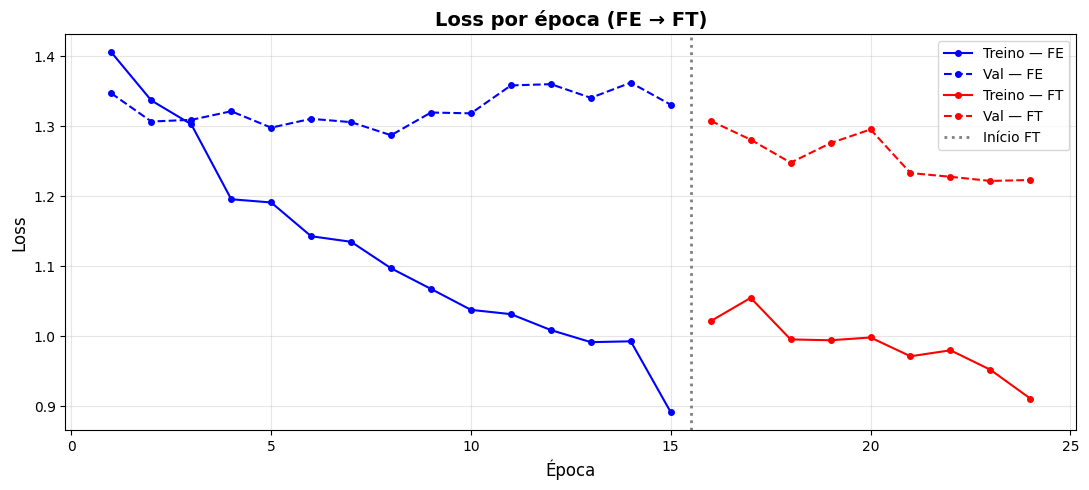

In [21]:
def plot_full_training(hist_fe, hist_ft, metric='train_acc', val_metric='val_acc', ylabel='Acurácia'):
    tr_fe = hist_fe[metric];   vl_fe = hist_fe[val_metric]
    tr_ft = hist_ft[metric];   vl_ft = hist_ft[val_metric]
    n_fe  = len(tr_fe)
    e_fe  = range(1, n_fe + 1)
    e_ft  = range(n_fe + 1, n_fe + len(tr_ft) + 1)

    plt.figure(figsize=(11, 5))
    plt.plot(e_fe, tr_fe, 'b-o',  ms=4, label='Treino — FE')
    plt.plot(e_fe, vl_fe, 'b--o', ms=4, label='Val — FE')
    plt.plot(e_ft, tr_ft, 'r-o',  ms=4, label='Treino — FT')
    plt.plot(e_ft, vl_ft, 'r--o', ms=4, label='Val — FT')
    plt.axvline(x=n_fe + 0.5, color='gray', linestyle=':', lw=2, label='Início FT')
    plt.xlabel('Época', fontsize=12); plt.ylabel(ylabel, fontsize=12)
    plt.title(f'{ylabel} por época (FE → FT)', fontsize=14, fontweight='bold')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

#plot_full_training(hist_cells_fe, hist_cells_ft, 'train_acc', 'val_acc', 'Acurácia')
plot_full_training(hist_cells_fe, hist_cells_ft, 'train_loss', 'val_loss', 'Loss')

**7.2 Avaliação no conjunto de validação e teste**

Avaliamos o modelo primeiro no conjunto de validação (usado durante o treino para monitorar o aprendizado) e depois no conjunto de teste, que foi mantido completamente separado e representa a estimativa mais honesta do desempenho em dados novos.

In [19]:
def get_predictions(model, loader):
    """Retorna arrays numpy de y_true e y_pred para um DataLoader."""
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_pred.extend(preds)
    return np.array(y_true), np.array(y_pred)

val_loss, val_acc   = eval_epoch(model_cells_ft, ds_val_c,  criterion_ft)
test_loss, test_acc = eval_epoch(model_cells_ft, ds_test_c, criterion_ft)

print(f"Validação — Loss: {val_loss:.4f}  |  Acurácia: {val_acc*100:.2f}%")
print(f"Teste     — Loss: {test_loss:.4f}  |  Acurácia: {test_acc*100:.2f}%")

Validação — Loss: 1.3079  |  Acurácia: 65.38%
Teste     — Loss: 1.3135  |  Acurácia: 60.38%


**7.3 Matriz de confusão**

Agora, analisamos com mais detalhe o desempenho do modelo por meio de uma matriz de confusão, que mostra como as previsões se comparam com os valores reais, permitindo identificar quais classes estão sendo bem classificadas e onde ocorrem mais erros.

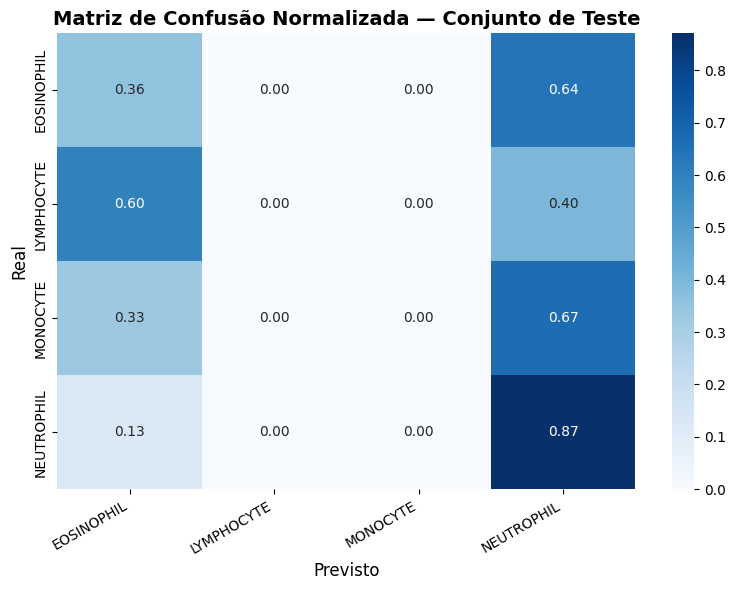

In [20]:
# Coleta predições no conjunto de teste
y_true_c, y_pred_c = get_predictions(model_cells_ft, ds_test_c)

cm = confusion_matrix(y_true_c, y_pred_c, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES_C, yticklabels=CLASS_NAMES_C)
plt.xlabel('Previsto', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusão Normalizada — Conjunto de Teste', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**7.4 Relatório de classificação**

Nesta etapa, geramos um relatório detalhado de classificação, que apresenta métricas como precisão, recall e F1-score para cada classe, permitindo uma análise mais completa do desempenho do modelo em cada tipo de leucócito.

In [24]:
print("Relatório de Classificação — Conjunto de Teste:\n")
print(classification_report(y_true_c, y_pred_c, target_names=CLASS_NAMES_C, digits=3))

Relatório de Classificação — Conjunto de Teste:

              precision    recall  f1-score   support

  EOSINOPHIL      0.385     0.357     0.370        14
  LYMPHOCYTE      0.000     0.000     0.000         5
    MONOCYTE      0.000     0.000     0.000         3
  NEUTROPHIL      0.675     0.871     0.761        31

    accuracy                          0.604        53
   macro avg      0.265     0.307     0.283        53
weighted avg      0.496     0.604     0.543        53



C:\Users\leticia25029\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\leticia25029\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\leticia25029\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

**7.5 Considerações sobre os resultados**

Mesmo com um número reduzido de imagens de treino, o uso de Transfer Learning permitiu que o modelo aprendesse alguns padrões relevantes, especialmente para a classe mais representada (neutrófilos), que apresentou desempenho significativamente superior às demais. O Fine-tuning contribuiu para uma melhor adaptação ao domínio das imagens de microscopia, embora esse ganho tenha sido mais evidente nas classes com maior número de exemplos. O uso de pesos de classe também ajudou a reduzir o viés do modelo, mas não foi suficiente para equilibrar completamente o desempenho entre as classes.

Apesar disso, os resultados evidenciam limitações importantes. O modelo apresentou grande dificuldade em identificar corretamente classes minoritárias, como monócitos, que não foram reconhecidos em nenhum dos casos. Isso reforça o impacto do forte desbalanceamento do dataset e da baixa quantidade de dados disponíveis. Além disso, a diferença entre o tipo de imagem utilizado no pré-treinamento e as imagens de microscopia, somada à variabilidade nas condições de preparo das lâminas, pode ter dificultado a capacidade de generalização do modelo.

### **8. Conclusão**

Ao final deste trabalho, conclui-se que o Aprendizado por Transferência é uma abordagem viável para treinar modelos mesmo com poucos dados, como no caso da classificação de leucócitos. Foi possível obter um modelo funcional, mas com desempenho desigual entre as classes, evidenciando o impacto do desbalanceamento e da baixa quantidade de dados.

Também foi observado que o Transfer Learning não é suficiente por si só, pois seu sucesso depende da similaridade entre os domínios e da qualidade do dataset. Para aplicações reais em diagnóstico, seriam necessários mais dados, validação clínica rigorosa e maior confiabilidade nas previsões.

Ainda assim, como prova de conceito, os resultados demonstram bem o potencial dessa técnica, especialmente em cenários com dados limitados.

*Uso de IA:* Para a realizacão desse notebook, utilizei o ChatGPT para me auxiliar no entendimento do que é aprendizado por transferência, principalmente na distinção de feature extractor e o fine-tuning, e para me auxiliar a compreender o dataset do ImageNet, que nunca tinha usado antes. Além disso, utilizei o ClaudeAI para compreender como eu poderia abordar um problema biológico (Classificação de Subtipos de Células Sanguíneas) usando o aprendizado por trasferência e, principalmente, como lidar com o problema de desbalanceamento do dataset.

### **9. Referências**

1. BROWNLEE, Jason. Transfer learning for deep learning. Machine Learning Mastery, [s.d.]. Disponível em: https://machinelearningmastery.com/transfer-learning-for-deep-learning/.

2. TRANSFER learning. Wikipedia, [s.d.]. Disponível em: https://en.wikipedia.org/wiki/Transfer_learning.

3. ABBES, Nessim. MobileNetV2 Autoencoder: an efficient approach for feature extraction and image reconstruction. Medium, [s.d.]. Disponível em: https://medium.com/@abbesnessim/mobilenetv2-autoencoder-an-efficient-approach-for-feature-extraction-and-image-reconstruction-9c70ba58947a.

4. PYTORCH. Transfer learning tutorial. PyTorch, [s.d.]. Disponível em: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html.

5. MOONEY, Paul Timothy. Blood cells. Kaggle, [s.d.]. Disponível em: https://www.kaggle.com/datasets/paultimothymooney/blood-cells.

6. KERAS. Keras documentation. Keras, [s.d.]. Disponível em: https://keras.io/.